![header-Airbnbemoji](img/header-Airbnbemoji.jpg)


# Airbnb Listings
This dataset consists of six files with Airbnb rental listings of six cities: Austin, Bangkok, Buenos Aires, Cape Town, Istanbul, and Melbourne. You can access them via the File menu or in the Context Panel at the top right of the screen next to Report, under Files. The data dictionary and filenames can be found at the bottom of this workbook.

Each row represents a listing with details such as coordinates, neighborhood, host id, price per night, number of reviews, and so on. 

We've added some guiding questions for analyzing this exciting dataset! Feel free to make this workbook yours by adding and removing cells, or editing any of the existing cells.

[Source: InsideAirbnb](http://insideairbnb.com)

### 🔍 **Scenario: Identify Trends Scross Listings Operated by _Inferred_ Professional Hosts**

This scenario helps you develop an end-to-end project for your portfolio.

**Background:** An international real estate firm has hired you to research professional hosting on Airbnb. These are hosts that have multiple listings, make considerable income from their listings, and often manage teams to operate their listings. Examples include property managers and hospitality business owners.

**Objective**: Using the data from all six cities, you'll have to infer listings by professional hosts based on the distribution of calculated_host_listings_count. The lead consultant is interested in whether you can identify trends across listings operated by inferred professional hosts, as well as an estimation of the percentage of listings on Airbnb operated by professional hosts.

You will need to prepare a report that is accessible to a broad audience. It will need to outline your motivation, analysis steps, findings, and conclusions.

## Data Inspection

In [1]:
# 0. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
au_o = pd.read_csv("data/listings_austin.csv") # Austin data
bg_o = pd.read_csv("data/listings_bangkok.csv") # Bangkok data
ba_o = pd.read_csv("data/listings_buenos_aires.csv") # Buenos Aires data
ct_o = pd.read_csv("data/listings_cape_town.csv") # Cape Town data
it_o = pd.read_csv("data/listings_istanbul.csv") # Istanbul data
mb_o = pd.read_csv("data/listings_melbourne.csv") # Melbourne data

au = au_o.copy()
bg = bg_o.copy()
ba = ba_o.copy()
ct = ct_o.copy()
it = it_o.copy()
mb = mb_o.copy()

# First Glance
au.head(n=5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2265,Zen-East in the Heart of Austin (monthly rental),2466,Paddy,NaN,78702,30.27752,-97.71377,Entire home/apt,179,7,26,2021-07-02,0.36,3,35,2,NaN
1,5245,"Eco friendly, Colorful, Clean, Cozy monthly share",2466,Paddy,NaN,78702,30.27614,-97.71320,Private room,114,30,9,2017-02-24,0.21,3,0,0,NaN
2,5456,"Walk to 6th, Rainey St and Convention Ctr",8028,Sylvia,NaN,78702,30.26057,-97.73441,Entire home/apt,108,2,575,2021-09-25,24.16,1,324,39,NaN
3,5769,NW Austin Room,8186,Elizabeth,NaN,78729,30.45697,-97.78422,Private room,39,1,264,2021-07-03,5.95,1,0,7,NaN
4,6413,Gem of a Studio near Downtown,13879,Todd,NaN,78704,30.24885,-97.73587,Entire home/apt,109,3,117,2021-04-02,1.27,1,0,4,NaN


In [2]:
# Combine datasets

## Add city column to each dataset
au["city"] = "Austin"
ba["city"] = "Buenos Aires"
bg["city"] = "Bangkok"
ct["city"] = "Cape Town"
it["city"] = "Istanbul"
mb["city"] = "Melbourne"

# Combine all datasets
all_data = pd.concat([au, ba, bg, ct, it, mb], ignore_index=True)

print(all_data.info())
print(all_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103817 entries, 0 to 103816
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              103817 non-null  int64  
 1   name                            103776 non-null  object 
 2   host_id                         103817 non-null  int64  
 3   host_name                       103745 non-null  object 
 4   neighbourhood_group             0 non-null       float64
 5   neighbourhood                   103817 non-null  object 
 6   latitude                        103817 non-null  float64
 7   longitude                       103817 non-null  float64
 8   room_type                       103817 non-null  object 
 9   price                           103817 non-null  int64  
 10  minimum_nights                  103817 non-null  int64  
 11  number_of_reviews               103817 non-null  int64  
 12  last_review     

At a first glance, we can identify the irrelevant/ null variables for further analysis - 'host_name', 'neighbourhood', 'neighbourhood_group', 'last_review', 'availability_365', 'number_of_reviews_ltm', 'license'.

In the full dataset, there are also some unusual values - max ``price`` is 12980 per night, max ``minimum_nights`` is 1100. Thus, the distribution of these variables will be inspected and outliers will be removed.

In the remaining numerical variables, no anomalies were detected.



In [3]:
# Removing irrelevant and null columns
cols_to_drop = ["host_name", "neighbourhood", "neighbourhood_group","last_review", "number_of_reviews_ltm", "license"]
all_data.drop(columns=cols_to_drop, inplace=True)

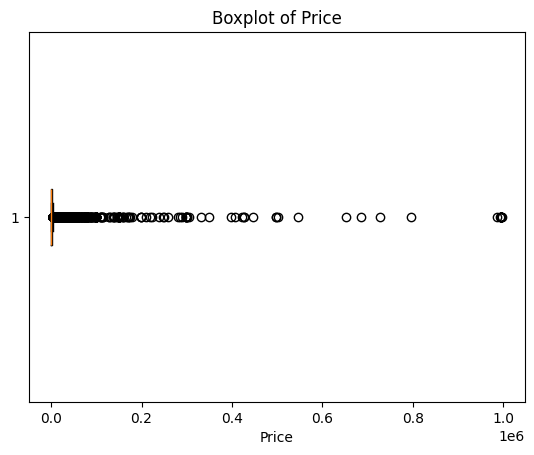

                                                    name        room_type  \
925                                       The Cathédrale  Entire home/apt   
3064                  New town home in nice neighborhood     Private room   
3345                                      SXSW Exclusive  Entire home/apt   
4103   Amazing Luxury in Downtown Austin perfect for ...  Entire home/apt   
4729          Colorful, Art-Filled East Austin Town-home     Private room   
...                                                  ...              ...   
95833  ⭐4Bedder Beautiful Comfy Family House with The...  Entire home/apt   
96917  ⭐3Bedder3.5bath Townhouse @DoncasterCloseWestf...  Entire home/apt   
97760                                No longer available     Private room   
99075  ⭐4BedderSpaciousHouse@RingwoodExplore Yarra Va...  Entire home/apt   
99130           ⭐3 bedder Cozy house with Centre Cooling  Entire home/apt   

       price  minimum_nights  
925    10000              30  
3064   10000 

In [4]:
# Outliers detection - price

plt.figure()
plt.boxplot(all_data["price"], vert=False)
plt.xlabel("Price")
plt.title("Boxplot of Price")
plt.show()

# Outlier inspection - price
print(all_data[all_data["price"] > 8000][["name", "room_type", "price", "minimum_nights"]])

Price is a highly skewed variable. In the **modelling** step, we will first perform a **log-transformation**.

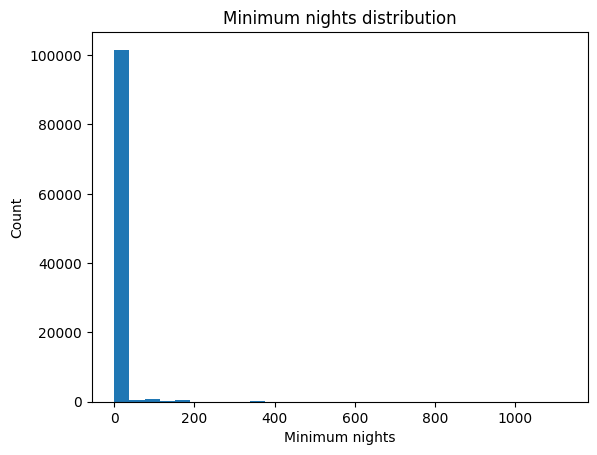

In [5]:
# Outliers detection - minimum_nights
plt.figure()
plt.hist(all_data["minimum_nights"], bins=30)
plt.xlabel("Minimum nights")
plt.ylabel("Count")
plt.title("Minimum nights distribution")
plt.show()

In [6]:
# Data Filtering
## Removing points w/ price > 4000
all_data = all_data[all_data["price"] <= 4000]

## Removing points w/ minimum_nights > 100
all_data = all_data[all_data["minimum_nights"] <= 30]

## Removing unavailable listings
all_data = all_data[all_data["availability_365"] > 0]

all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79610 entries, 0 to 103816
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              79610 non-null  int64  
 1   name                            79575 non-null  object 
 2   host_id                         79610 non-null  int64  
 3   latitude                        79610 non-null  float64
 4   longitude                       79610 non-null  float64
 5   room_type                       79610 non-null  object 
 6   price                           79610 non-null  int64  
 7   minimum_nights                  79610 non-null  int64  
 8   number_of_reviews               79610 non-null  int64  
 9   reviews_per_month               53515 non-null  float64
 10  calculated_host_listings_count  79610 non-null  int64  
 11  availability_365                79610 non-null  int64  
 12  city                            7961

In [7]:
# Save cleaned dataset
all_data.to_csv("data/clean_data.csv", index=False)

**Objective:** 

- infer listings by professional hosts based on the distribution of calculated_host_listings_count; 

- identify trends across listings operated by inferred professional hosts.


## Data Exploration

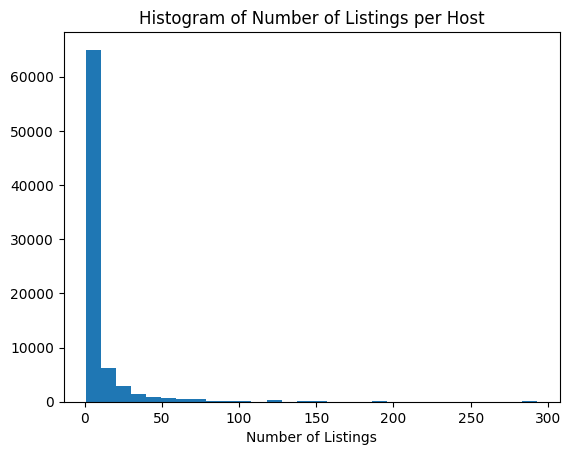

In [8]:
# Number of listings per host

plt.figure()
plt.hist(all_data["calculated_host_listings_count"], bins=30)
plt.xlabel("Number of Listings")
plt.title("Histogram of Number of Listings per Host")
plt.show()

Highly skewed number of listings, indicating that the majority of hosts own 10 or less listings.

In [9]:
# Feature engineering - professional host
pro_listings = 3
all_data["professional_host"] = (all_data["calculated_host_listings_count"] >= pro_listings)

# Percentage of professional hosts per city
print("Percentage of professional hosts per city:")
print(all_data.groupby("city")["professional_host"].mean().sort_values(ascending=False) * 100)
print("\nPrice statistics by type of hosts per city:")
print(all_data.groupby(["city", "professional_host"])["price"].median().unstack())

Percentage of professional hosts per city:
city
Bangkok         60.649987
Istanbul        47.747833
Melbourne       44.588823
Austin          43.637650
Cape Town       41.385914
Buenos Aires    32.468806
Name: professional_host, dtype: float64

Price statistics by type of hosts per city:
professional_host   False   True 
city                             
Austin              170.0   175.0
Bangkok            1129.0   990.0
Buenos Aires       2288.0  2388.0
Cape Town           927.0  1074.0
Istanbul            350.0   501.0
Melbourne           120.0   131.0


In terms of the type of host composition, it is interesting to note that Bangkok (47%) and Istanbul (35%) rely much more on professional hosts, while the Buenos Aires (20%) and Austin (23%) market is mostly composed by particular hosts.

C:\Users\carol\AppData\Local\Temp\ipykernel_16388\1468648479.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


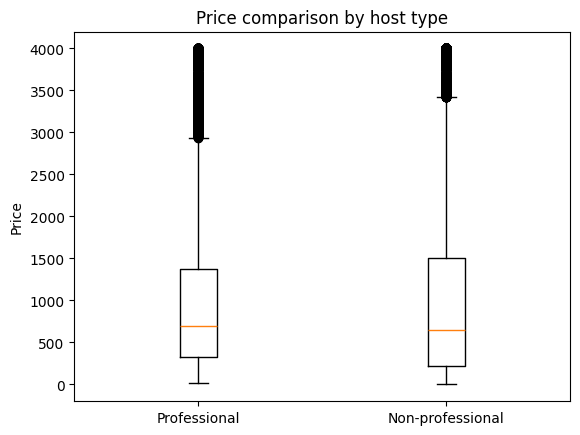

In [10]:
# Price comparison by host type

plt.figure()
plt.boxplot(
    [all_data.loc[all_data["professional_host"], "price"],
     all_data.loc[~all_data["professional_host"], "price"]],
    labels=["Professional", "Non-professional"])
plt.ylabel("Price")
plt.title("Price comparison by host type")
plt.show()

No clear difference in price is observed between professional and particular hosts.

In [11]:
print(pd.crosstab(all_data["room_type"], all_data["professional_host"], normalize="columns"))
print(all_data.groupby("professional_host")[["number_of_reviews", "reviews_per_month"]].median())

professional_host     False     True 
room_type                            
Entire home/apt    0.645461  0.650360
Hotel room         0.004662  0.044672
Private room       0.331204  0.281080
Shared room        0.018672  0.023889
                   number_of_reviews  reviews_per_month
professional_host                                      
False                            2.0               0.51
True                             3.0               0.58


## Key Insights

Professional hosts display an identical behaviour to the particular hosts